In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime.fake_provider import FakeAlmadenV2
from numpy.random import Generator, PCG64
from qiskit_aer import AerSimulator
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import EstimatorV2 as Estimator

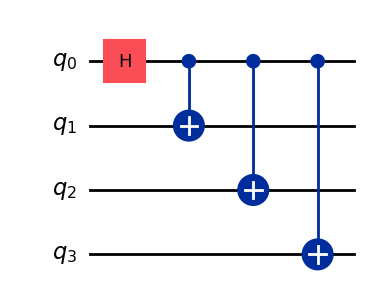

In [2]:
# Create a new circuit with two qubits
qc = QuantumCircuit(4)

# Add a Hadamard gate to qubit 0
qc.h(0)

# Perform a controlled-X gate on qubit 1, controlled by qubit 0
qc.cx(0, 1)
qc.cx(0, 2)
qc.cx(0, 3)

# Return a drawing of the circuit using MatPlotLib ("mpl").
# These guides are written by using Jupyter notebooks, which
# display the output of the last line of each cell.
# If you're running this in a script, use `print(qc.draw())` to
# print a text drawing.
qc.draw("mpl")

In [3]:
# Set up six different observables.


observables = [SparsePauliOp("ZIZZ")]

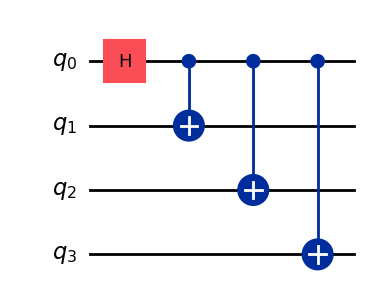

In [5]:
backend = AerSimulator(method="statevector")
print(backend.configuration())
# Convert to an ISA circuit and layout-mapped observables.
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)
isa_circuit.draw("mpl")

In [9]:
from qiskit_ibm_runtime.options.utils import UnsetType
from qiskit_ibm_runtime import EstimatorOptions

# Run:
mapped_observables = [
    observable.apply_layout(isa_circuit.layout) for observable in observables
]
my_options = EstimatorOptions()
# Turn off all error mitigation and suppression
# my_options.resilience_level = 0
# my_options.default_shots = 420
# my_options.default_precision = 0.1
my_options.default_shots = None
my_options.seed_estimator = 42
# my_options.simulator.seed_simulator = 42
# print(my_options)
# my_options.options.environment.log_level = "DEBUG"
# QISKIT_IBM_RUNTIME_LOG_LEVEL = "DEBUG"
# QISKIT_IBM_RUNTIME_LOG_FILE = "LOGGER.txt"
estimator = Estimator(backend, options=my_options)
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
seed = 42
seed = Generator(PCG64(seed))
estimator = AerEstimator.from_backend(backend, options={"default_precision" : 0.1,
                                                        # "run_options": {"seed_simulator":42}
                                                        })


# from qiskit.primitives import StatevectorEstimator
# if isinstance(my_options.default_precision, UnsetType):
#     precision = 0.0
# else:
#     precision = my_options.default_precision
# # if isinstance(my_options.simulator.seed_simulator, UnsetType):
# #     seed = None
# # else:
# #     seed = my_options.simulator.seed_simulator
# seed = 42
# seed = Generator(PCG64(seed))
# estimator = StatevectorEstimator(default_precision=precision, seed=seed)
# mapped_observables = observables
# isa_circuit = qc


# print(backend.run(isa_circuit).result())
values = []
for _ in range(1000):
    pubs = [(isa_circuit, mapped_observables)]


    job = estimator.run(pubs)
    full_result = job.result()
    print(full_result[0].data)
    for pub_result in full_result:
        values.append(pub_result.data.evs[0])
print(values)

DataBin(evs=np.ndarray(<shape=(1,), dtype=float64>), stds=np.ndarray(<shape=(1,), dtype=float64>), shape=(1,))
DataBin(evs=np.ndarray(<shape=(1,), dtype=float64>), stds=np.ndarray(<shape=(1,), dtype=float64>), shape=(1,))
DataBin(evs=np.ndarray(<shape=(1,), dtype=float64>), stds=np.ndarray(<shape=(1,), dtype=float64>), shape=(1,))
DataBin(evs=np.ndarray(<shape=(1,), dtype=float64>), stds=np.ndarray(<shape=(1,), dtype=float64>), shape=(1,))
DataBin(evs=np.ndarray(<shape=(1,), dtype=float64>), stds=np.ndarray(<shape=(1,), dtype=float64>), shape=(1,))
DataBin(evs=np.ndarray(<shape=(1,), dtype=float64>), stds=np.ndarray(<shape=(1,), dtype=float64>), shape=(1,))
DataBin(evs=np.ndarray(<shape=(1,), dtype=float64>), stds=np.ndarray(<shape=(1,), dtype=float64>), shape=(1,))
DataBin(evs=np.ndarray(<shape=(1,), dtype=float64>), stds=np.ndarray(<shape=(1,), dtype=float64>), shape=(1,))
DataBin(evs=np.ndarray(<shape=(1,), dtype=float64>), stds=np.ndarray(<shape=(1,), dtype=float64>), shape=(1,))
D

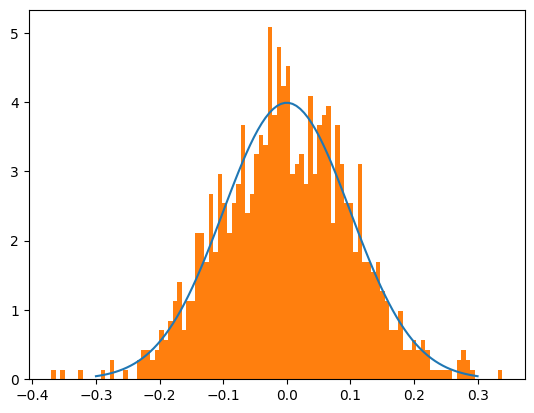

In [10]:
# This is the result from our single pub, which had six observables,
# so contains information on all six.
import scipy.stats as stats


mu = 0
variance = 0.1**2
sigma = np.sqrt(variance)
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma))
plt.hist(values, density=True, bins=100)
plt.show()

These discrete peaks are due to the following effect:
- The only physically possible measurements are -1 and +1.
- For a given precision $p$ the estimator takes $\sim \frac{1}{p^2}$ shots from -1 and +1.
- The values can only combine to discrete values for a small amount of shots.

In [8]:
old_values = np.array(values.copy())

In [11]:
for a,b in zip(values, old_values):
    print(a-b)

-0.03148436885466127
-0.17963416039612626
-0.0754861801065973
0.2194007422624643
-0.14223833007540543
-0.05622515309366474
-0.20596289674436102
0.17248171404473328
0.03842996282194541
-0.0072490666108547715
-0.08323062527493509
0.1337709187695113
0.08796785440777047
0.0034900192448136663
-0.18453300146945642
0.020705702971936815
0.04821005091198057
0.259049755591807
-0.15011285040200562
0.01008205198771393
-0.5413336322003184
-0.01105865235425943
0.08909836619329953
-0.16367265798037592
-0.06837210693788023
0.14997060139331542
-0.015533927856953504
0.18642612558814647
0.13538859404017875
0.16310017582406142
0.0834971161308133
0.15195360216907286
-0.08298023925214197
0.3426653921350023
0.0431573144678124
-0.13938692999167143
-0.07012798246490586
0.04687346473212352
0.24251145109792074
-0.15378734051142068
0.224779300809304
0.28911467329444906
0.39510390669846535
0.06228648112145604
-0.11396065318614544
0.1617047618876049
0.21493848383681025
0.014491222777634382
0.08812156815910636
-0.15

In [12]:
my_options.default_precision

Unset